# GRADTDA5622 - Big Data Computing Foundations 2
## Case Study 1: CRISP_DM Step 2 Data Understanding (with Exploratory Data Analysis)
Replace the example information below with your real information:
- Semester: Spring 2026 (FILL IN)
- Instructor: Brad Coy (FILL IN)
- Section:  (FILL IN) (if applicable)
- Student Name(s): Clay Morgan (FILL IN)
- Student Email(s): morgan.1461@osu.edu (FILL IN)
- Student ID(s): 500293216  (FILL IN)

Based on CRISP-DM Template Version V12.
***

***
# Section: Overview
- Insert a short description of the scope of this exercise, any supporting information, etc.
- **(I will fill this in for each assignment - Tom Bihari)**
***

### Assignment Overview
In this assignment, you will analyze an ALTERED copy of the “Hotel Booking Demand” dataset.
- This dataset was pulled on 4/8/22 from: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
- The dataset file is named: **hotel_bookings_with_errors_V1.csv**

**The data has been altered slightly for use in course assignments,etc.:**
- A unique ROW attribute has been added.
- Errors have been added, such as: duplicated records, deleted records, deleted attribute values, erroneous attribute values.
**DO NOT PUBLISH THIS DATASET - it contains intentionally wrong data!**

This assignment covers the **Step 2 - Data Understanding** of the six steps of the **CRISP-DM process model** (and very briefly Step 1 - Business Understanding).

The **objectives** of this assignment are:
- By analyzing and thinking critically about the data, you may identify interesting charcteristics that would be useful when deciding **if** and **how** to use the data.
- The results of this step will help set the stage for Step Three (3), in which you may create a final, cleaned-up dataset that can be used for deeper analysis and model-building in the future.

### Problem Statement
Assume that you are the Director of Data Science for Buckeye Resorts, Inc. (BRI), an international hotel chain.  As is the case for all hotel chains, reservation cancellations cause significant impacts to BRI, in profitability, logistics, and other areas.  The cost to BRI of a cancelled reservation is $500 on average.

- BRI wants to improve (decrease) the cancellation rates at its hotels, using more tailored interventions, based on newly available detailed data.  BRI processes 100,000 reservations per year, so an incremental improvement in cancellation rates would have a significant impact.

- One intervention being considered is to offer a special financial incentive to customers who have reservations, but who are “at risk” of cancellation.  BRI has performed a small pilot test, and has found that offering a $100 discount to a customer who is planning to cancel is effective 30% of the time in inducing the customer not to cancel (by locking in a no-cancellation clause in exchange for the discount).

- BRI leadership has asked your team to analyze the new data, and determine if it is suitable for developing analyses and models that would be effective in predicting which future reservations are likely to be at risk of cancellation, so the aforementioned financial incentive could be offered.

- The head of BRI would then like you attend the upcoming BRI Board of Directors meeting.  She has asked you to present your findings to her and to the BOD, to help them decide whether to go forward with the planned tailored intervention approach, and/or to adjust or abandon the approach.  Your goal is to support the BOD in making a decision.

You decide to look at the dataset and **explore (understand)** its contents.  You **do not** need to create (prepare) a clean dataset from it at this time, and you do not yet know the specific algorithm, formula or model you will use to predict cancellations.  **That will come in later steps.**

### Things To Do
Complete the sections for the first two steps of CRISP-DM in this notebook.  Some intial guidance / sugggestions:
- **Business Understanding**: **Briefly** fill in the cells, using your thoughts on the specific item.  This is strictly for practice, for your benefit - it will not be graded rigorously.  You may leave cells empty or say "I don't know.", etc., if the topic is irrelevant.  **Don't spend a lot of time on it.**
- **Data Understanding**: There are many attributes in this dataset. Once you have done some initial analysis, you may choose to concentrate on ones that seem more promising or useful.  However, you must give evidence and explain why the attributes that you choose to give less attention warrant the lack of attention.

It is essential that you **communicate** your goals, thought process, actions, results, and conclusions to the **audience** that will consume this work.  It is **not enough** to show just the code.  It is not appropriate to show long sections of **unexplained printout**, etc.  Be kind to your readers and provide value to them!

**ALWAYS follow this pattern** when doing **each portion** of the work.  This allows us to give feedback and assign scores, and to give partial credit.  Make it easy for the reader to understand your work.
- Say (briefly) **what** you are trying to do, and **why**.
- Do it (code).
- Show or describe the **result** clearly (and briefly as needed), and explain the significant **conclusions or insights** derived from the results.

**HAVE FUN!**

***
# Section: Setup
- Add any needed imports, helper functions, etc., here.
***

In [55]:
import numpy as np
import pandas as pd

#!pip install matplotlib
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
#matplotlib.use('Qt5Agg')

import seaborn as sns

pd.set_option('display.max_columns', 50) #include to avoid ... in middle of display

***
# Section: 1 - Business Understanding
- This step is essential (and occasionally ignored…).  It focuses on understanding the business needs and objectives, and defining a data analysis problem that is relevant and useful to the business, so the right solution is built.

- Consider the following questions and discuss the possible answers to them in the spaces below.
  - It is OK to say that you do not know.  How might you get answers to the questions?
  - You may consider some of the questions to be "not applicable".  If so, why?
  - You may choose to use markdown instead of raw text in the answer cells, to make them "pretty" and easy to read.
***

**Context**
- What is the overview, history, big picture?

At buckeye resorts inc, there is an issue where hotel reservation cancellations are a big financial ding on the bottomline of the company. The company is looking into a way to mitigate as many hotel cancellations as possible. Since these cost $500 on average.

**Business Objectives**
- What is the problem or opportunity to be addressed / solved?
- What is its business value?

The problem to be solved is finding a way to reduce the number of cancellations to reservations. The value of this is high since the total cost of a cancellation is on average $500, with a $100 incentive, this could mitigate the risk of a cancellation and save $400 in value.

**Stakeholders**
- Who are they?
- What are their needs?

The stakeholders involved are:
- The board of directors: They desire a way to decrease costly cancellations to their hotel chains, and need information to make the decision.
- The customers: The customers have a direct financial stake in this, as the amount of money they pay for a hotel could decrease if they take the $100 offer but would be giving up flexibility in cancellation
- Buckeye Resorts Inc.: The bottom line of the company is impacted, if it is found that there is a way to mitigate cancellations, more money would be leftover as profit.



**General Goals**
- Understand the past/current state (descriptive)?
- Predict the future (predictive)?
- Mine for unknown patterns / insights?
- Answer questions?  What are they?
- Support decisions?  What are they?

The general goal is to predict the future, with a model that can accurately predict the likelyhood that a customer is going to cancel. Ultimately it is a way of supporting decisions because the board of directors will need to determine if it is worthwhile to implement the tech.

**Scope**
- What is the specific scope of the project?
- What, specifically, is NOT in scope?  (What are you not doing that someone might think you are doing?)
Is the scope flexible?  In what way?

In scope: Using the provided data to determine if you can realiably predict a cancellation beforehand.
NOT in scope: Determining the offer or the level of discount offered to customers.

**Deliverables**
- Report?
- Reusable code?
- Presentation?

A presentation showing the results of the model in front of the head and the board of directors. Reusable code for implementing the model if it is decided to do so for these purposes.

**Success Criteria**
- What, specifically, must be accomplished for this project to be a success?

In order for this project to be a success, a model must be fit and evaluated for accuracy before the results are presented to the board.

**Solution Approach**
- Is this a “one time” (throw away) solution?
- Or will the solution become part of repeated process that is used and enhanced over time?

This solution will become a part of a repeated process that is enhanced and used over time, IF it is determined to be of use by the board of directors.

**Quality**
- What level of Correctness or Confidence is needed?
- Is this life-critical or are we looking for ‘directionally correct’ results?

This project is looking for a confident result. If a user is likely going to cancel and the model can predict this and ultimately intervene and save money with a small discount offered, that is great. However, if the model is overly sensitive and offers discounts to too many customers this can quickly become a cost drain in itself. Therefore, the results need to be accurate and not overly sensitive.

**Constraints**
- Are there legal / regulatory implications (privacy, security, liability, HIPAA, FERPA)?
- Are there architectural constraints?

General personal data security practices depending on the dataset, if financial data is present this will need to be handled carefully. No architectural constraints immediately noticed.

**Time / Cost**
- What is the deadline or budget?

No explicit deadline or budget is stated other than the time before the next board of directors meeting.

**Dependencies**
- Is this project dependent on any other project or activity?
- Is any other project or activity dependent on this project?

**Resources Needed**
- Do you potentially need access to specific people, data, etc?

Access to the aforementioned detailed data is required.

**Other Considerations**
- What other considerations, not covered above, might be relevant?

***
# Section: 2 - Data Understanding
- Perform exploratory data analysis of the dataset by looking at individual attributes and/or combinations of attributes. You should focus on identifying and describing interesting observations and insights that you might uncover from the data.
- You should not simply provide the basic EDA information for all attributes in the data. Instead, you should focus on those that are more interesting or important, and provide some discussion of what you observe. Pay particular attention to potentially interesting bivariate (two-variable) relationships, as well as the relationship between each attribute and the class attribute (if this is a classification problem).
- This step includes:
  - Understanding what data might be available and relevant.
  - Acquiring the data.
  - Understanding the characteristics of the data (e.g., quality, completeness, currency, consistency,…).
  - Understanding how other datasets might enhance or supplement the data (and acquiring that data as well).
  - Possibly performing some initial analysis to build confidence that the overall direction is likely to be helpful to the business problem to be solved.

**NOTE:** Frequently, a first pass is made through the data to fix or remove "obvious" data quality issues (missing values, duplicate records, outliers (some), etc.).  The deeper Data Understanding analysis then is done on the "cleaned" data.  This mitigates the issue of bad data skewing the data analysis results.  **For this example, we will not do this separate first pass.**
***

***
## Section: 2.1 - Describe the meaning and type of data for each attribute.

Identify the type of data for each attribute.
  - Categorical: Nominal, Ordinal
  - Numerical: Interval, Ratio
  - Other: Complex or unstructured data (e.g., text strings, images,...)
  
NOTES:
  - This determines what operations are "meaningful" for each attribute.  For example, you can't add two Ordinal attributes.
  - You can't always tell the attribute types from the data itself.  For example, an Integer attribute could be Ordinal or Interval.

Identify interesting characteristics of the data (e.g., quality, completeness, currency, consistency,…).
  - Is this dataset relevant and appropriate for the goals of this project?
    - If not, what could you do? (find other data to replace or supplement this dataset, etc.)
***

### **Examine the meta-data (e.g., from data dictionary) available for the dataset.**  
#### As a reminder, the meta-data can be found [here](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand).

**Discussion:**
- hotel: resort or city hotel
- is_cancelled: boolean 1(cancelled), 0(not)
- lead_time: integer of days between entering date to system and arrival date
- arrival_date_year: integer of year of arrival
- arrival_date_month: string of month of arrival
- arrival_date_week: integer week number of arrival (1-53)
- arrival_date_day: integer of date (1-31)
- stays_in_weekend: integer number of weekend S-S nights stayed
- stays_in_week_nights: integer number of week nights M-F stayed
- adults: integer of number of adults
- children: integer of number of children
- babies: integer of number of babies
- meal: type of meal booked - nominal categorical
- country: nominal categorical ISO format country of origin
- market_segment: nominal categorical
- distribution_channel: nominal categorical
- is_repeated_guest: boolean for repeated guest (1) or not (0)
- previous_cancellations: integer of number of previous bookings cancelled by the customer
- previous_booking_not_cancelled: integer of number of previous bookings not cancelled prior
- reserved_room_type: nominal (maybe ordinal if room increases in size?) categorical room type
- assigned_room_type: nominal categorical, actual assigned to booking room type code
- booking_changes: number of changes made to booking integer
- deposit_type: Categorical indicating whether a deposit was paid or not
- agent: ID of travel agency nominal categorical, null if none
- comapny: company of the booking
- days_in_waiting_list: integer number of days booking was in waiting list before confirmed.
- customer_type: nominal cateogircal type of booking
- adr: dividing sum of all lodging transactions by total number of staying nights integer
- required_car_parking: integer number of parking spaces required by the customer
- total_of_special_requests: number of special reqs
- reservation_status: last status, cancelled, checked out
- reservation_status_date: date at which last status was changed

### **Load the Dataset.**

In [2]:
#OPTIONAL: Load it only once per session, and save it, so we don't waste time.
import pandas as pd

#NOTE: You may need to change the path to the data file, depending on your setup.

try:
    _ = data_from_source_file_df
    print("Reusing source data")
except:
    print("Loading source data")
    # data_from_source_file_df = pd.read_csv("../shared_Sp23/hotel_bookings_with_errors_V1.csv") [if mirroring Dr. Bihari's setup]
    data_from_source_file_df = pd.read_csv("https://bcoy48.github.io/osu-gradtda-5622-sp25/course_materials/case_studies/1/hotel_bookings_with_errors_V1.csv")
data_df = data_from_source_file_df
print("Done!")

Loading source data
Done!


In [3]:
# Print the schema, based on the data in the file.
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119391 entries, 0 to 119390
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ROW                             119391 non-null  int64  
 1   hotel                           119391 non-null  object 
 2   is_canceled                     119390 non-null  float64
 3   lead_time                       119391 non-null  int64  
 4   arrival_date_year               119391 non-null  int64  
 5   arrival_date_month              119391 non-null  object 
 6   arrival_date_week_number        119391 non-null  int64  
 7   arrival_date_day_of_month       119391 non-null  int64  
 8   stays_in_weekend_nights         119391 non-null  int64  
 9   stays_in_week_nights            119391 non-null  int64  
 10  adults                          119391 non-null  int64  
 11  children                        119387 non-null  float64
 12  babies          

In [4]:
data_df.describe()
# First data impressions:
# at least one record with 0 adults? look into that eventually - could be an error
# 26 previous cancellations? seems unlikely - will investigate further
# 391 days on waiting list, many standard deviations from the mean
# negative ADR value
# 8 car parking spaces - many stdevs again

,ROW,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119391.000000,119390.000000,119391.000000,119391.000000,119391.000000,119391.000000,119391.000000,119391.000000,119391.000000,119387.000000,...,119391.000000,119391.000000,119391.000000,119391.000000,103051.00000,6797.000000,119391.000000,119391.000000,119391.000000,119391.000000
mean,59694.000050,0.370408,104.010662,2016.156544,27.165172,15.798117,0.927591,2.500297,1.856572,0.103889,...,0.031912,0.087117,0.137096,0.221122,86.69487,189.266735,2.321130,101.831089,0.062517,0.571366
std,34465.357245,0.482916,106.862967,0.707481,13.605081,8.780897,0.998613,1.908278,0.582185,0.398560,...,0.175766,0.844333,1.497431,0.652303,110.77504,131.655015,17.594648,50.535580,0.245290,0.792796
min,0.000000,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.00000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,29846.500000,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,9.00000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,59694.000000,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,14.00000,179.000000,0.000000,94.590000,0.000000,0.000000
75%,89541.500000,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,229.00000,270.000000,0.000000,126.000000,0.000000,1.000000
max,119389.000000,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,...,1.000000,26.000000,72.000000,21.000000,535.00000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
# checking out numeric cols that seem to have some level of meaning (ex, a boolean doesnt make sese to look into)
# agent/company are identification numbers

# some erronous data and outliers may exist in this dataset BUT mostly looks good so far

In [5]:
# look into the object data cols
# arrival_date_month, meal, country, market_segment, distribution_channel, reserved_room_type, assigned_room_type, deposit_type, customer_type, reservation_status, reservation_status_date
# ensure no typos for the next few
data_df['arrival_date_month'].value_counts() # all 12 months represented



,count
arrival_date_month,
August,13877
July,12662
May,11791
October,11160
April,11089
June,10939
September,10508
March,9794
February,8068


In [6]:
data_df['meal'].value_counts() #NOTE: 1169 undefined values, 4 categories

,count
meal,
BB,92311
HB,14463
SC,10650
Undefined,1169
FB,798


In [7]:
data_df['country'].value_counts() # assuming all these are correct

,count
country,
PRT,48590
GBR,12130
FRA,10415
ESP,8568
DEU,7287
...,...
MRT,1
KIR,1
SDN,1


In [8]:
data_df['market_segment'].value_counts() # NOTE: 2 undefined and 1 clear typo

,count
market_segment,
Online TA,56477
Offline TA/TO,24219
Groups,19811
Direct,12606
Corporate,5295
Complementary,743
Aviation,237
Undefined,2
Onlin TA,1


In [9]:
data_df["distribution_channel"].value_counts() # 5 undefined

,count
distribution_channel,
TA/TO,97871
Direct,14645
Corporate,6677
GDS,193
Undefined,5


In [10]:
# reserved_room_type, assigned_room_type, deposit_type, customer_type, reservation_status, reservation_status_date
data_df['reserved_room_type'].value_counts() # P and L are much lower on the alphabet than the rest, could be real, low counts, could be a typo, unsure as of yet

,count
reserved_room_type,
A,85995
D,19201
E,6535
F,2897
G,2094
B,1118
C,932
H,601
P,12


In [11]:
data_df['assigned_room_type'].value_counts()

,count
assigned_room_type,
A,74054
D,25322
E,7806
F,3751
G,2553
C,2375
B,2163
H,712
I,363


In [12]:
data_df['deposit_type'].value_counts()

,count
deposit_type,
No Deposit,104642
Non Refund,14587
Refundable,162


In [13]:
data_df['customer_type'].value_counts()

,count
customer_type,
Transient,89614
Transient-Party,25124
Contract,4076
Group,577


In [14]:
data_df['customer_type'].value_counts()

,count
customer_type,
Transient,89614
Transient-Party,25124
Contract,4076
Group,577


In [15]:
# transform this data into datetime to evaluate futher
data_df['reservation_status_date'] = pd.to_datetime(data_df['reservation_status_date'])
print(f'Min Date: {data_df['reservation_status_date'].min()}')
print(f'Max Date: {data_df['reservation_status_date'].max()}') # this is the date range we are working with.

Min Date: 2014-10-17 00:00:00
Max Date: 2017-09-14 00:00:00


**Discussion:**
There appears to be some outliers in the data such as 391 days being the longest waitlist time, this could be an informative outlier or could be a misinput, unsure yet. I do not see any issues with the boolean values. Some value descriptions do not make any logical sense like the agent being an identification number, so those can be ignored for now. There are some minor missing data values in the object datatypes. A couple of clear typos like "Onlin TA" which will be cleaned up later on.

In [104]:
# # Create some simple lists for future use
all_attribute_names = list(data_df)
print(all_attribute_names)
class_attribute_name = ['is_canceled']
nominal_attribute_names = [
    'hotel',
    'arrival_date_month',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'assigned_room_type',
    'deposit_type',
    'customer_type',
    'reservation_status'
]
ordinal_attribute_names = [
    'reserved_room_type' # assuming heirachal by letter>
]
categorical_attribute_names = nominal_attribute_names + ordinal_attribute_names
interval_attribute_names = [
    'arrival_date_year',
    'arrival_date_week_number',
    'arrival_date_day_of_month'
]
ratio_attribute_names = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]
numerical_attribute_names = interval_attribute_names + ratio_attribute_names

['ROW', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


**Discussion:**
From this, I am pretty confident in some rows that could be deleted and updated with some missing or clearly erroneous data. I am aware of the scope of the variables now as well and have a list of things to look out for soon here.

***
## Section: 2.2 - Provide basic statistics for the attributes.
- For example: counts, percentiles, mean, median, standard deviation. The statistics should be relevant for the type of attribute.
***

In [ ]:
# # This is an optional step.  Pandas Profiling is a library that provides a sophisticated profiling report
# #  that can be saved in the form of an interactive HTML file.  See: https://pypi.org/project/pandas-profiling/
# #  It may run very slowly on large datasets.  It is best to limit the number of records to profile, based on
# #  experimentation with your computer.  You can do so by profiling small samples from large datasets.
# #  You also can specify the "minimal=True" argument in newer versions of the library.
# # To install, uncomment and run the following line (one time).
#!pip install pandas_profiling

# import pandas_profiling
# if data_df.shape[0] > 500:
#     profile = pandas_profiling.ProfileReport(data_df.sample(n=500))  # Limit to a small set of records.
#     #profile = pandas_profiling.ProfileReport(data_df, minimal=True)  # Limit to the simpler profiling.
# else:
#     profile = pandas_profiling.ProfileReport(data_df)
# profile.to_file("./profilereport.html")

# # Set plotting back to interactive mode (pandas_profiling sets it to non-interactive)
# %matplotlib inline

# Found the updated version of pandas_profiling to run this on
# Install (run once)
!pip install ydata-profiling

from ydata_profiling import ProfileReport

if data_df.shape[0] > 500:
    profile = ProfileReport(data_df.sample(n=500), minimal=True)
else:
    profile = ProfileReport(data_df)

profile.to_file("profilereport.html")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: multimethod
    Found existing installation: multimethod 2.0.2
    Uninstalling multimethod-2.0.2:
      Successfully uninstalled multimethod-2.0.2
  Attempting uninstall: visions
    Found existing installation: visions 0.7.4
    Uninstalling visions-0.7.4:
      Successfully uninstalled visions-0.7.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.


/tmp/ipykernel_10747/3918302343.py:23: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install data-profiling via `pip install data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 33/33 [00:01<00:00, 28.88it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

**Discussion:**
ROW col is just an index, will probably drop it. company has mostly missing values - will drop this column. Agent is also missing 13.6% based on my report, will look into this one further, potentailly could add a 'No agent' value for the missing data points.



In [67]:
data_df.describe() #calculates statistics for all numerical columns

,ROW,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,119391.000000,119390.000000,119391.000000,119391.000000,119391.000000,119391.000000,119391.000000,119391.000000,119391.000000,119387.000000,119391.000000,119391.000000,119391.000000,119391.000000,119391.000000,103051.00000,6797.000000,119391.000000,119391.000000,119391.000000,119391.000000,119391
mean,59694.000050,0.370408,104.010662,2016.156544,27.165172,15.798117,0.927591,2.500297,1.856572,0.103889,0.007949,0.031912,0.087117,0.137096,0.221122,86.69487,189.266735,2.321130,101.831089,0.062517,0.571366,2016-07-30 00:20:03.467598336
min,0.000000,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,6.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,29846.500000,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.00000,62.000000,0.000000,69.290000,0.000000,0.000000,2016-02-01 00:00:00
50%,59694.000000,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.00000,179.000000,0.000000,94.590000,0.000000,0.000000,2016-08-07 00:00:00
75%,89541.500000,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.00000,270.000000,0.000000,126.000000,0.000000,1.000000,2017-02-08 00:00:00
max,119389.000000,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.00000,543.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,34465.357245,0.482916,106.862967,0.707481,13.605081,8.780897,0.998613,1.908278,0.582185,0.398560,0.097436,0.175766,0.844333,1.497431,0.652303,110.77504,131.655015,17.594648,50.535580,0.245290,0.792796,NaN


**Discussion:**
Note that there are some suspicious values above.  These may be data quality issues.  Suggestions:
-

***
## Section: 2.3 - Visualize / analyze the most important or interesting attributes using appropriate techniques.
- For each visualization, provide an interpretation explaining why it is appropriate or interesting. What does each visualization tell us?
***

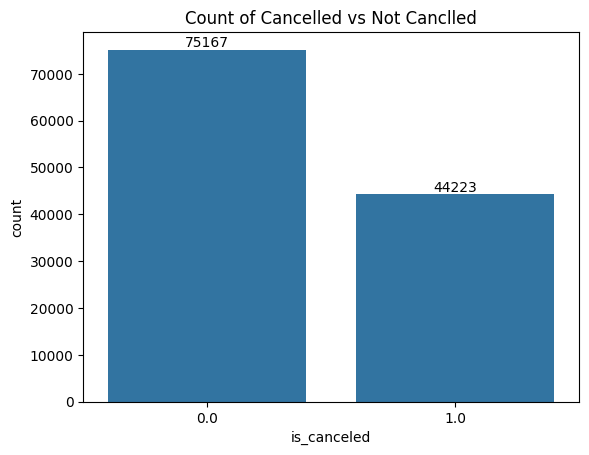

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(
    data=data_df,
    x="is_canceled"
)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Count of Cancelled vs Not Canclled")
plt.show()
# 1 indicated cancelled, 0 not cancelled.
# Approximately more than 1/3rd of the data is cancelled reservations
# Should allow for good training split

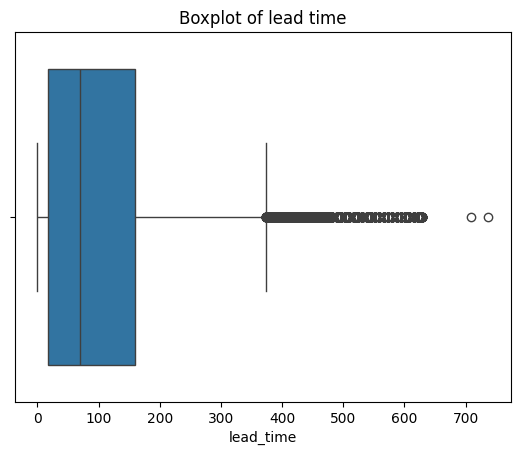

In [45]:
# Going to plot the numeric variables that I find the most interesting or potentially useful
sns.boxplot(
    data=data_df,
    x="lead_time"
)
plt.title("Boxplot of lead time")
plt.show()
# A LOT of outliers present above around 400

<Axes: xlabel='arrival_date_week_number', ylabel='Count'>

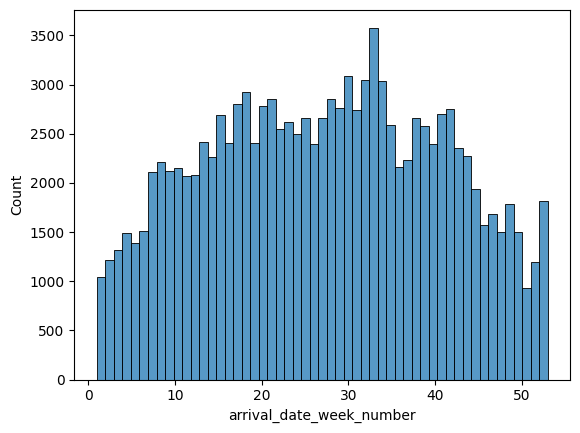

In [39]:
# Spread of arrival date week
sns.histplot(
    data=data_df,
    x="arrival_date_week_number",
    bins=53
)
# distribution of weeks seems to make sense - nothing suspiscious of note

<Axes: xlabel='stays_in_weekend_nights'>

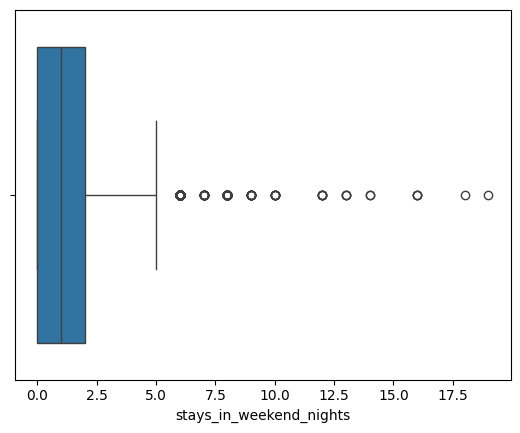

In [44]:
# boxplot of weekend nights
sns.boxplot(
    data=data_df,
    x="stays_in_weekend_nights"
)
# a lot of outliers, 18+ weekend nights would indicate a ~9 week vacation...
# will look into that individual record

In [48]:
data_df[data_df['stays_in_weekend_nights'] > 15]
# Seems to make sense, likely not an error

,ROW,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
9840,9839,Resort Hotel,1.0,322,2017,January,2,10,16,40,...,No Deposit,8.0,NaN,0,Transient,25.50,0,0,Canceled,2016-10-31
14038,14037,Resort Hotel,0.0,113,2015,August,31,1,18,42,...,No Deposit,NaN,NaN,0,Transient,110.50,0,3,Check-Out,2015-09-30
14039,14038,Resort Hotel,0.0,126,2016,July,28,5,19,50,...,No Deposit,NaN,NaN,0,Transient,110.00,0,3,Check-Out,2016-09-12
33925,33924,Resort Hotel,0.0,71,2017,January,2,10,16,40,...,No Deposit,196.0,NaN,0,Transient,28.79,0,0,Check-Out,2017-03-07
101795,101794,City Hotel,0.0,140,2016,September,39,22,16,41,...,No Deposit,9.0,NaN,0,Transient,8.34,0,2,Check-Out,2016-11-18


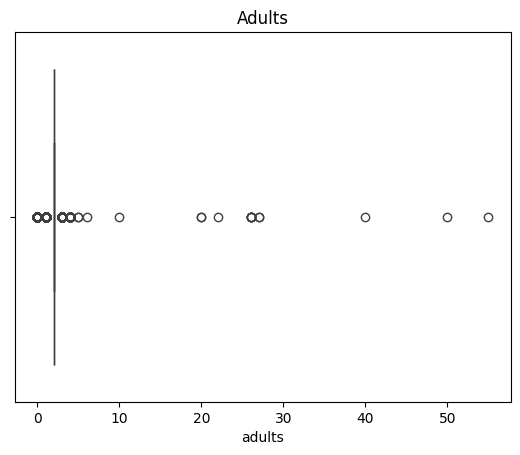

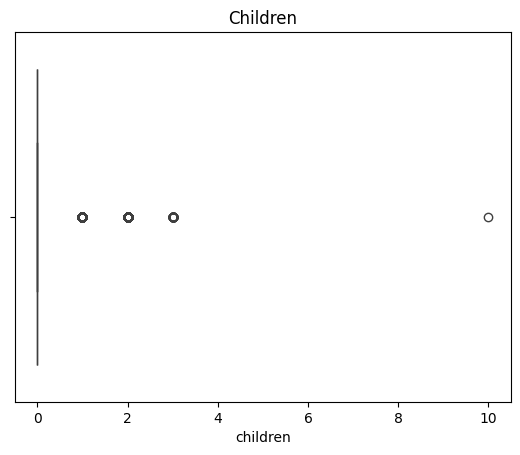

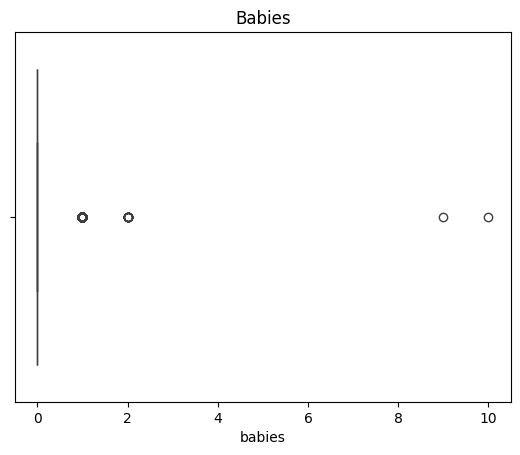

In [53]:
# plot adults, children, etc
sns.boxplot(
    data=data_df,
    x="adults"
)
plt.title("Adults")
plt.show()

sns.boxplot(
    data=data_df,
    x="children"
)
plt.title("Children")
plt.show()

sns.boxplot(
    data=data_df,
    x="babies"
)
plt.title("Babies")
plt.show()

In [56]:
# investigating some of the outliers here
data_df[data_df["adults"] > 30]

,ROW,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
1540,1539,Resort Hotel,1.0,304,2015,September,36,3,0,3,40,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
1644,1643,Resort Hotel,1.0,336,2015,September,37,7,1,2,50,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-18
2174,2173,Resort Hotel,1.0,338,2015,October,41,4,2,0,55,0.0,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02


In [65]:
data_df[data_df["adults"] == 0]
# Likely missing data for 403 rows. Some have children with no adults which seems highly unlikely.
# Possibly will impute adult data?

,ROW,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2225,2224,Resort Hotel,0.0,1,2015,October,41,6,0,3,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,NaN,174.0,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06
2410,2409,Resort Hotel,0.0,0,2015,October,42,12,0,0,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,NaN,174.0,0,Transient,0.00,0,0,Check-Out,2015-10-12
3182,3181,Resort Hotel,0.0,36,2015,November,47,20,1,2,0,0.0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38.0,NaN,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23
3685,3684,Resort Hotel,0.0,165,2015,December,53,30,1,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308.0,NaN,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04
3709,3708,Resort Hotel,0.0,165,2015,December,53,30,2,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308.0,NaN,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117205,117204,City Hotel,0.0,296,2017,July,30,27,1,3,0,2.0,0,BB,GBR,Online TA,TA/TO,0,0,0,B,A,0,No Deposit,9.0,NaN,0,Transient,98.85,0,1,Check-Out,2017-07-31
117275,117274,City Hotel,0.0,276,2017,July,31,30,2,1,0,2.0,0,BB,DEU,Online TA,TA/TO,0,0,0,B,B,1,No Deposit,9.0,NaN,0,Transient,93.64,0,2,Check-Out,2017-08-02
117304,117303,City Hotel,0.0,291,2017,July,30,29,2,2,0,2.0,0,BB,PRT,Online TA,TA/TO,0,0,0,B,A,0,No Deposit,9.0,NaN,0,Transient,98.85,0,1,Check-Out,2017-08-02
117454,117453,City Hotel,0.0,159,2017,July,31,31,1,3,0,2.0,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,9.0,NaN,0,Transient,121.88,0,1,Check-Out,2017-08-04


In [64]:
# most children, 10 vs 2 adults. Probably real?
data_df[data_df["children"] > 5]

,ROW,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
329,328,Resort Hotel,1.0,55,2015,July,29,12,4,10,2,10.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,2,No Deposit,8.0,NaN,0,Contract,133.16,0,1,No-Show,2015-07-12


In [66]:
# babies outliers
data_df[data_df['babies'] > 5]
# seems rather implausible to have 1 adult and 9 babies in a corporate dist?

,ROW,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
46620,46619,City Hotel,0.0,37,2016,January,3,12,0,2,2,0.0,10,BB,PRT,Online TA,TA/TO,0,0,0,D,D,1,No Deposit,9.0,NaN,0,Transient,84.45,0,1,Check-Out,2016-01-14
78657,78656,City Hotel,0.0,11,2015,October,42,11,2,1,1,0.0,9,BB,GBR,Corporate,Corporate,0,0,0,A,B,1,No Deposit,95.0,NaN,0,Transient-Party,95.00,0,0,Check-Out,2015-10-14


<Axes: xlabel='booking_changes'>

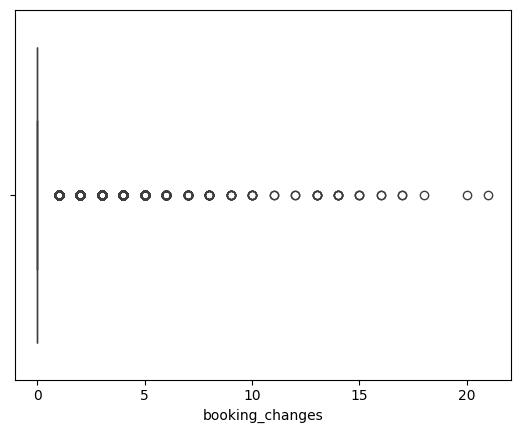

In [96]:
sns.boxplot(
    data=data_df,
    x="booking_changes"
) # anything that is not 0 is considered an outlier

<Axes: xlabel='adr'>

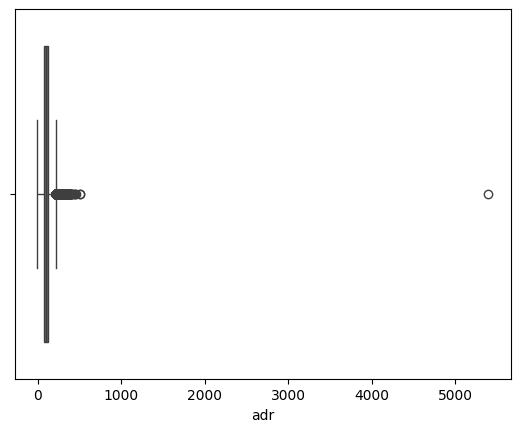

In [97]:
sns.boxplot(
    data=data_df,
    x="adr"
)# extreme outlier should likely be removed

**Discussion:**
Note that there are some suspicious values above.  These may be data quality issues.  Suggestions:
- There are certainly some issues, such as values that are multiple standard deviations away from the mean (ex, 19 weekend nights).
- From here a few approaches could be taken:
  - any significant outliers like this could be dropped completely from the dataset as they represent a smaller fraction of the data.
  - Some of the values could likely be relatively easily imputed with mean values.
    - Cases where adults == 0, since the mean is very strongly concentrated around 2 I think imputing this data would make the most sense for these rows.
  - In the situation where extreme outliers stand, such as 8 parking spaces requested, I believe dropping the data row here makes more sense, as it could influence the model to weigh this too heavily.


***
## Section: 2.4 - Verify data quality: explain any missing values, duplicate data, or outliers.
- What, if anything, do you need to do about these? Be specific.
***

### **Missing Attribute Values**

In [ ]:
# the plan is to go through any missing values and determine what should or should not be done with each
data_df.isna().sum()

,0
ROW,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0


**Discussion:**
Suggested actions:
- Remove company column, since almost the entire column has missing values
- Remove the single is_cancelled column
- The 4 missing records from the children row, could easily be removed as its only 4, could also be filled with 0. Likely will have little effect either way with size of dataset
- country column is the most difficult to determine what to do with. There is a significant amount of missing values at 488 and I will probably test running a model with an 'Unknown' value and a version with those missing value rows removed
- Additionally: some rows like "adults" have many 0 values which makes little logical sense.

### **Duplicate Records**

In [70]:
# Find duplicated records
data_df[data_df.duplicated(keep=False)]
# 1 duplicate record

,ROW,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,5,Resort Hotel,0.0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,5,Resort Hotel,0.0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [83]:
# since ROW is just an index, drop row then check out any other possible duplicate record
df_no_row = data_df.drop(columns=['ROW'])

df_no_row[df_no_row.duplicated(keep=False)]

# data_df.duplicated(subset=data_df.columns.drop('ROW')).sum()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0.0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0.0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
6,Resort Hotel,0.0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0.0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
23,Resort Hotel,0.0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119353,City Hotel,0.0,63,2017,August,35,31,0,3,3,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0.0,63,2017,August,35,31,0,3,3,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119355,City Hotel,0.0,63,2017,August,35,31,0,3,3,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119373,City Hotel,0.0,175,2017,August,35,31,1,3,1,0.0,0,BB,NLD,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,42.0,NaN,0,Transient,82.35,0,1,Check-Out,2017-09-04


**Discussion:**
Suggested actions:
-
- With this many unique rows I generally find it hard to believe that a naturally occuring duplicate record could exist.
- Dropping the row column there is a lot of duplicate records.
- However, it is unknown exactly how many rooms this hotel is, and if the records seem to be "normal" within reason it is very possible that 2 adults had the same room type booked on the same date with the same depost $, etc.
  - Especially in peak months with July being strongly represented, etc
- Will plan to drop the duplicate with the same row and keep the rest.

### **Outliers**
- There are many ways to discover and handle outliers, and many resources online.  Here is a nice discussion:
- https://stackoverflow.com/questions/23199796/detect-and-exclude-outliers-in-a-pandas-dataframe

In [95]:
import pandas as pd
import numpy as np
from scipy import stats

# subset the numeric columns and check for outliers
numeric_cols = interval_attribute_names + ratio_attribute_names

numeric_data_df = data_df[numeric_cols]

z_scores = np.abs(stats.zscore(numeric_data_df, nan_policy='omit'))

numeric_data_df[(z_scores >= 3).any(axis=1)]

,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
0,2015,27,1,342,0,0,2,0.0,0,0,0,3,0,0.00,0,0
1,2015,27,1,737,0,0,2,0.0,0,0,0,4,0,0.00,0,0
13,2015,27,1,68,0,4,2,0.0,0,0,0,0,0,97.00,0,3
16,2015,27,1,68,0,4,2,0.0,0,0,0,0,0,97.00,0,3
19,2015,27,1,0,0,1,22,0.0,0,0,0,0,0,107.42,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119351,2017,35,30,286,0,4,2,0.0,0,0,0,0,0,112.05,0,3
119357,2017,35,29,111,1,5,2,0.0,0,0,0,3,0,135.00,0,1
119366,2017,35,27,54,3,5,1,0.0,0,0,0,0,0,266.75,0,1
119377,2017,35,29,165,1,5,3,0.0,0,0,0,0,0,209.25,0,3


**Discussion:**
Suggested actions:
- When it comes to outliers there is a lot of possibilities
- Some of these are outliers solely because most are 0, like booking_changes, and its likely not uncommon to have a couple booking changes on a single reservation occasionally, and could potentially contribute to cancelation.
- Some extreme outliers like a 5000+ value for adr should likely just be deleted, as if it is real it will throw off the model anyway since it is not a typical occurance.

***
## Section: 2.5 - Explore the relationships among the attributes.
- You may include or exclude the class attribute as appropriate.
- Use scatter plots, correlation matrices, cross-tabulations, group-wise averages, or other appropriate techniques. Explain and interpret any interesting relationships.
- There are three general cases for 2-attribute relationships:
  - Categorical vs Categorical
  - Categorical vs Numerical
  - Numerical vs Numerical
***

### **Categorical Attribute vs Categorical Attribute**

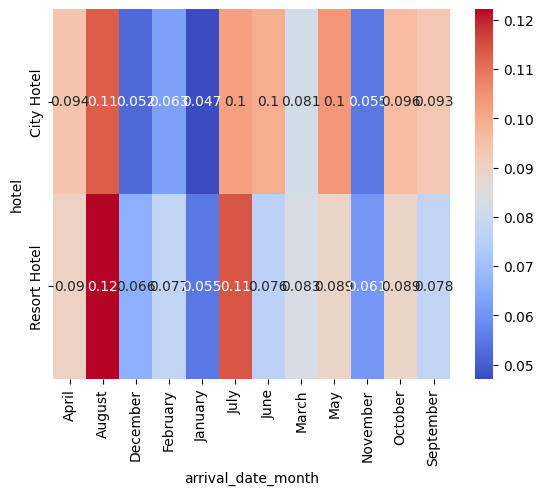

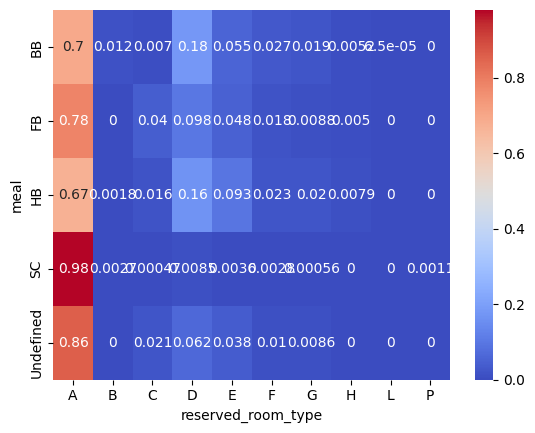

In [120]:
#categorical_attribute_names
'''
['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status',
 'reserved_room_type']
'''
# going to map categorical values that I think could be the most correlated
# Resort hotels likely has more arrivals during spring and summer months
sns.heatmap(pd.crosstab(
    data_df["hotel"],
    data_df["arrival_date_month"],
    normalize="index"
), annot=True, cmap="coolwarm")
plt.show() # Lines up mostly with what was expected, however city hotels are also busy aroudn these times

# meal vs reserved room type
sns.heatmap(pd.crosstab(
    data_df["meal"],
    data_df["reserved_room_type"],
    normalize="index"
), annot=True, cmap="coolwarm")
plt.show() # no relationship, A room is very popular regardless of meal

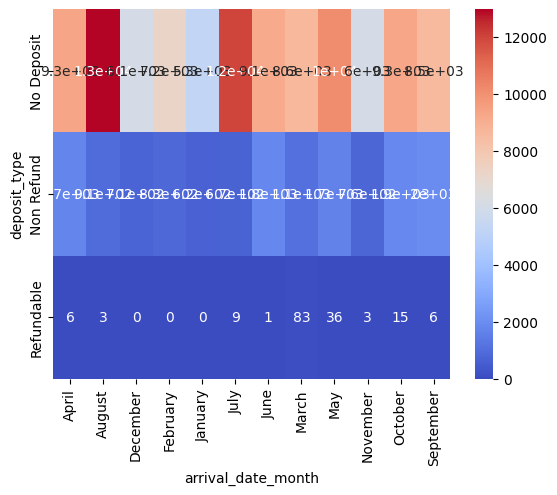

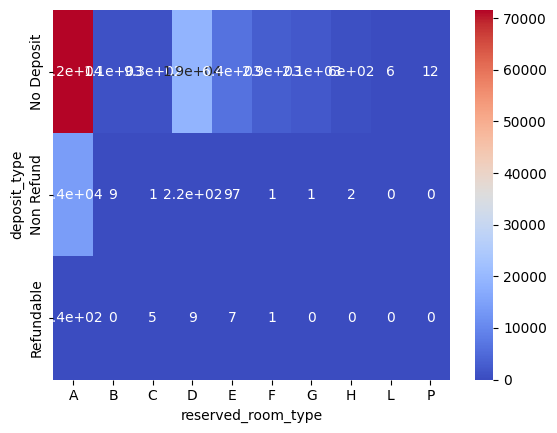

In [126]:
sns.heatmap(pd.crosstab(
    data_df["deposit_type"],
    data_df["arrival_date_month"],
    normalize="index"
), annot=True, cmap="coolwarm")
plt.show() # strangely refundable deposits are almost always in March?

sns.heatmap(pd.crosstab(
    data_df["deposit_type"],
    data_df["reserved_room_type"],
    normalize="index"
), annot=True, cmap="coolwarm")
plt.show() # likely just reflects the popular A room type

<Axes: xlabel='customer_type', ylabel='market_segment'>

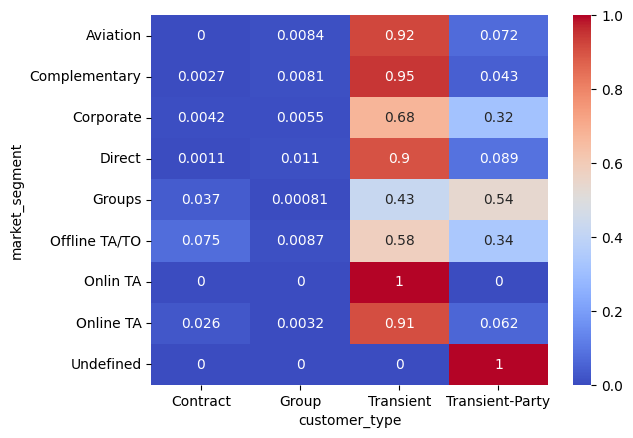

In [130]:
sns.heatmap(pd.crosstab(
    data_df['market_segment'],
    data_df['customer_type'],
    normalize="index"
), annot=True, cmap="coolwarm")

**Discussion:**
- Do not notice a whole ton of significant relationships between categorical value, with the exception of things like the A room often having no deposit, etc.

### **Categorical Attribute vs Numerical Attribute**

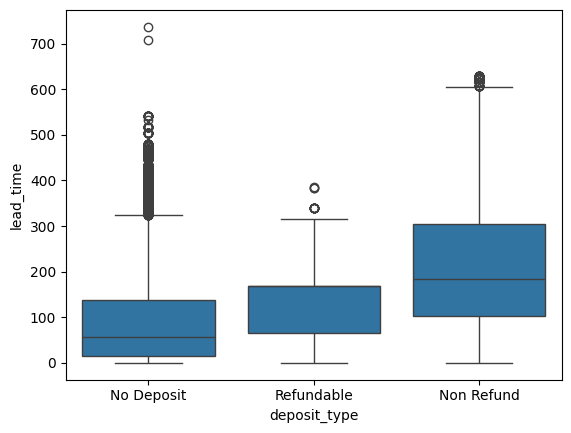

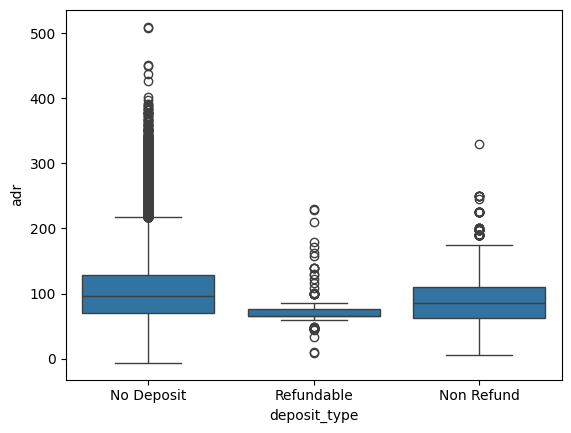

<Axes: xlabel='deposit_type', ylabel='total_of_special_requests'>

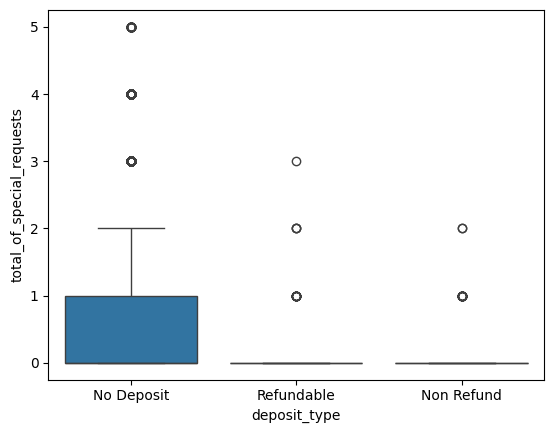

In [142]:
# I think that deposit type will "likely" have one of the bigger impacts on cancellations, will investigate a few relations here
sns.boxplot(data=data_df, x="deposit_type", y="lead_time")
plt.show()
# lead time is longer in non refundable reservations

# remove the outlier to see data better
data_df_rm = data_df[data_df['adr'] < 5000]
sns.boxplot(data=data_df_rm, x="deposit_type", y="adr")
plt.show() # both nonrefundable and no deposit types will often spend more than those who had a refundable deposit (very tightly spread)

sns.boxplot(data=data_df, x="deposit_type", y="total_of_special_requests") # no deposits often have more special requests

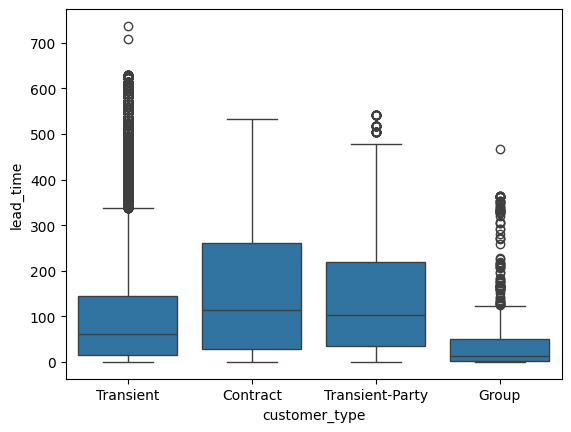

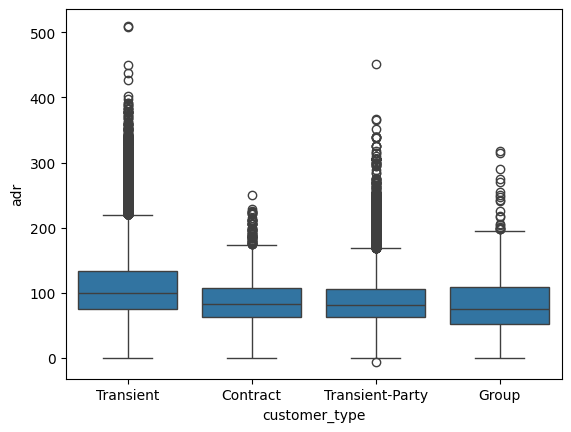

In [145]:
# csutomer type
sns.boxplot(data=data_df, x="customer_type", y="lead_time")
plt.show() # group customers have the lowest lead times by a decent margin on average

sns.boxplot(data=data_df_rm, x="customer_type", y="adr")
plt.show() # generally all around the same after outlier removed for clarity



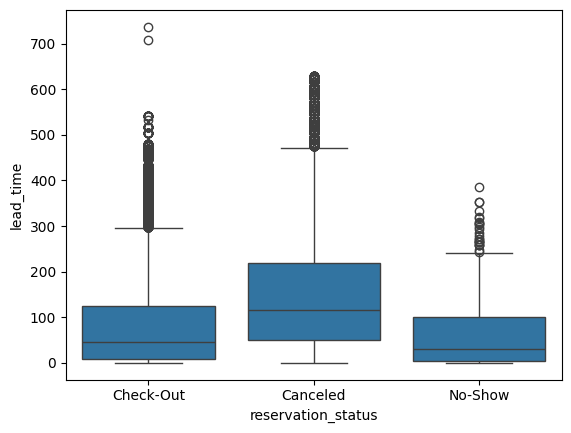

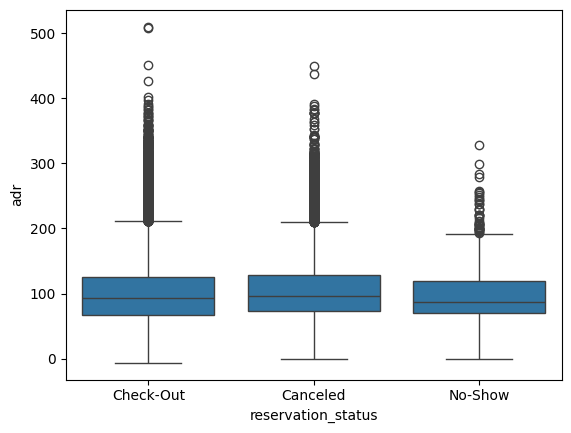

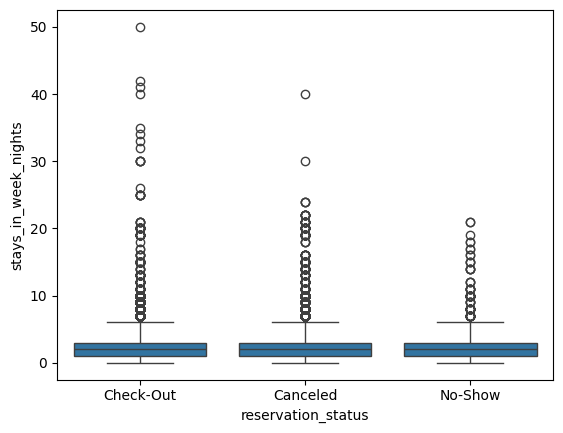

In [153]:
sns.boxplot(data=data_df_rm, x="reservation_status", y="lead_time")
plt.show()
# those with longer lead times are more likely to cancel!

sns.boxplot(data=data_df_rm, x="reservation_status", y="adr")
plt.show() # little effect

sns.boxplot(data=data_df_rm, x="reservation_status", y="stays_in_week_nights")
plt.show() # no relationship apparent

**Discussion:**
- Please fill in a response...

### **Numerical Attribute vs Numerical Attribute**

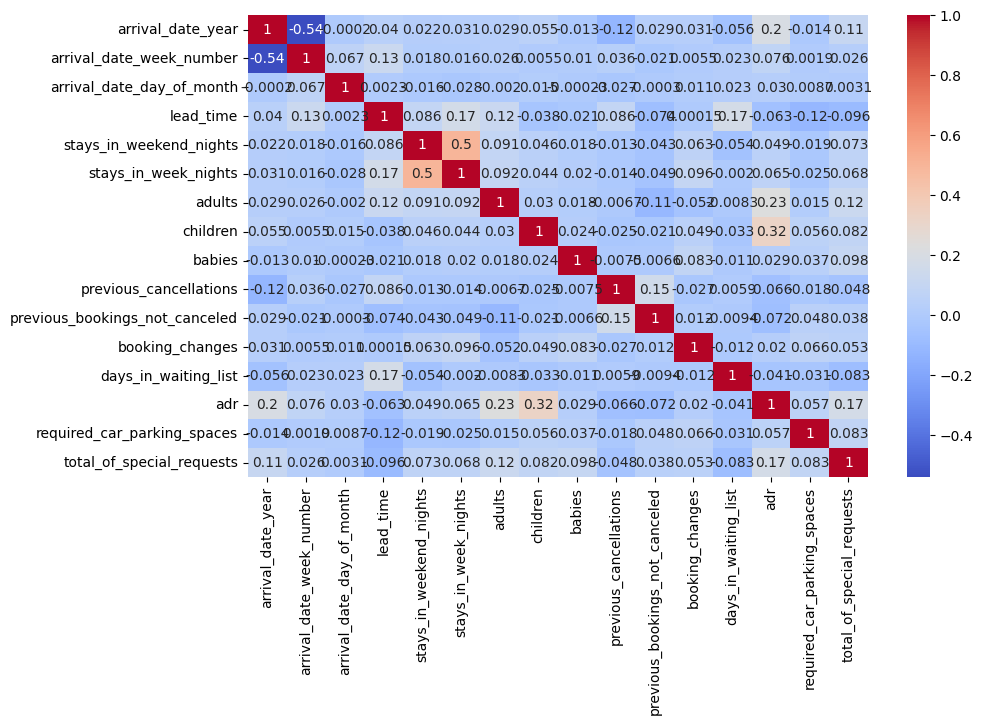

In [111]:
corr = data_df[numerical_attribute_names].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

**Discussion:**
- Not very much correlation between numerical values
- Values like "arrival_dat_year" and "arrival_date_week_number" are strongly negatively correlated, but this makes no sense as the week number and year number do not have a realtionship.
- Logically it makes sense that stays in weekend nights and stays in weekday nights would be positively correlated.
- Most notably perhaps is that ADR and children/adults have a weak positive correlation, essentially meaning that the more people present on the stay, the more money will be spent.

***
## Section: 2.6 - Identify and explain any interesting relationships between the class attribute and the other attributes.
- You may refer to earlier analyses / visualizations (if you included the class attribute above) or create new ones.
***

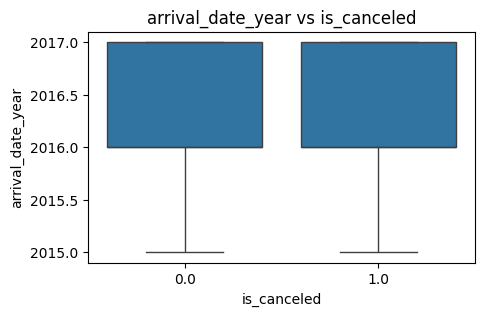

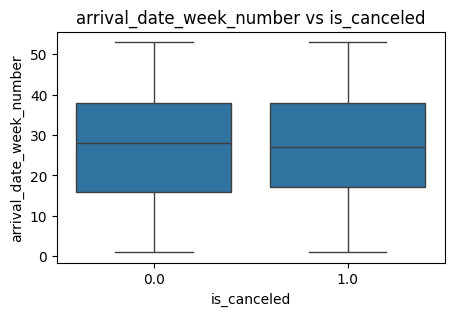

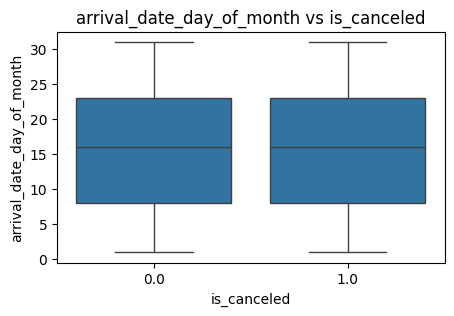

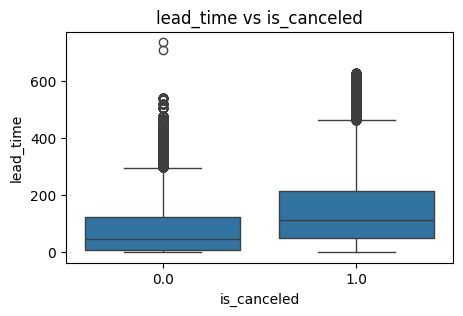

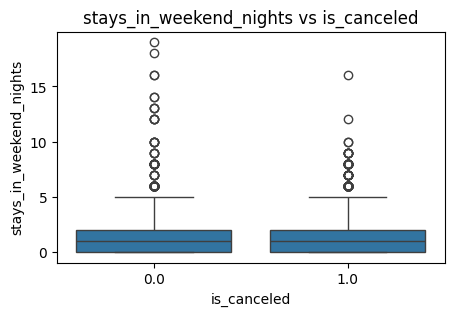

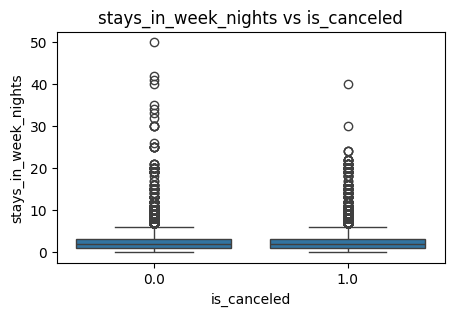

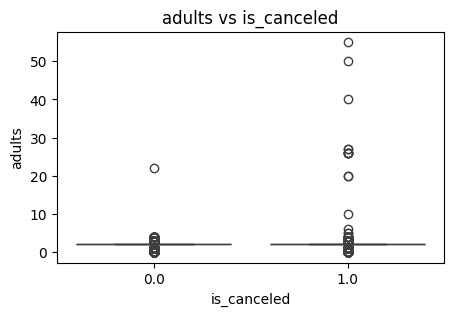

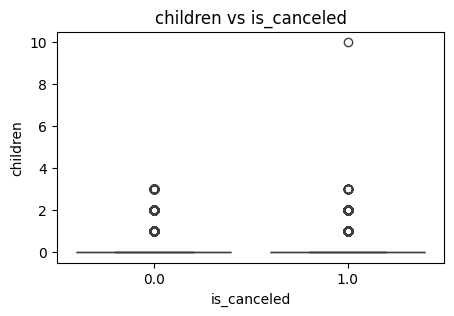

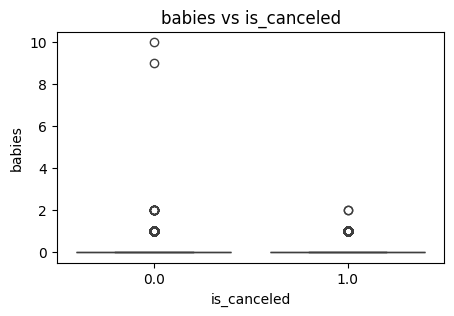

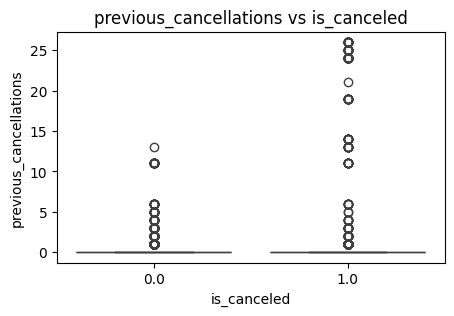

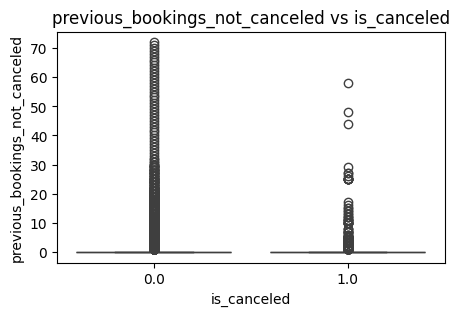

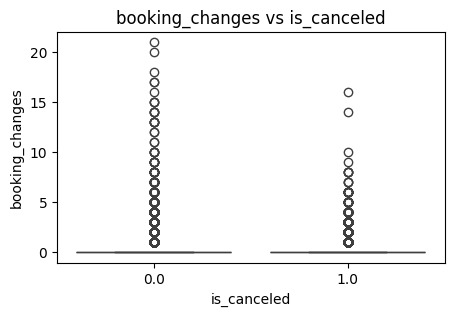

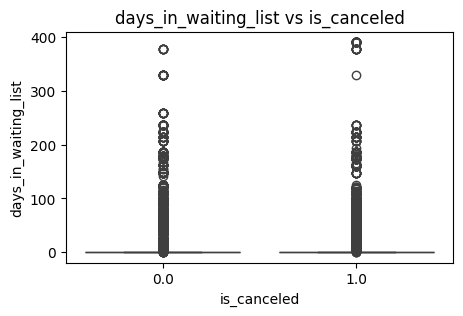

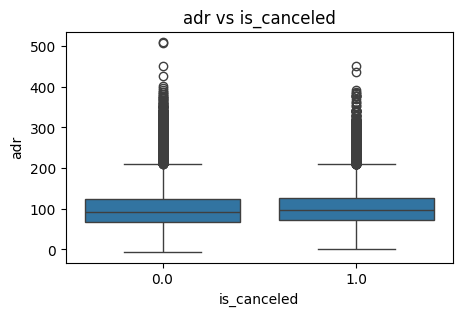

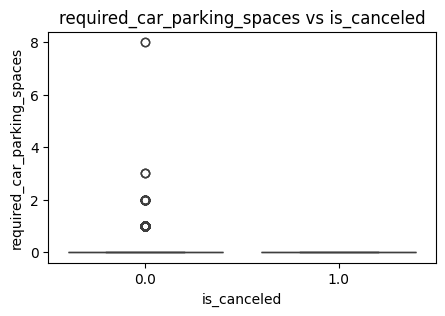

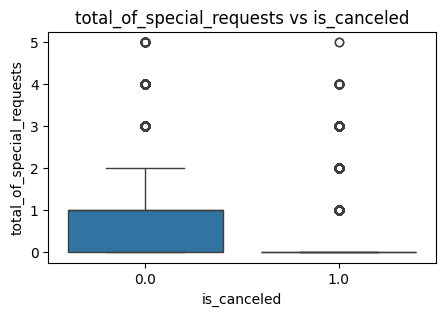

In [158]:
class_attribute_name

for col in numerical_attribute_names:
    plt.figure(figsize=(5, 3))
    sns.boxplot(data=data_df_rm, x="is_canceled", y=col)
    plt.title(f"{col} vs is_canceled")
    plt.show()

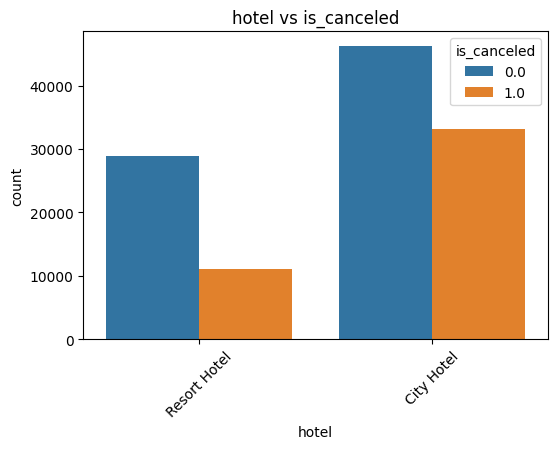

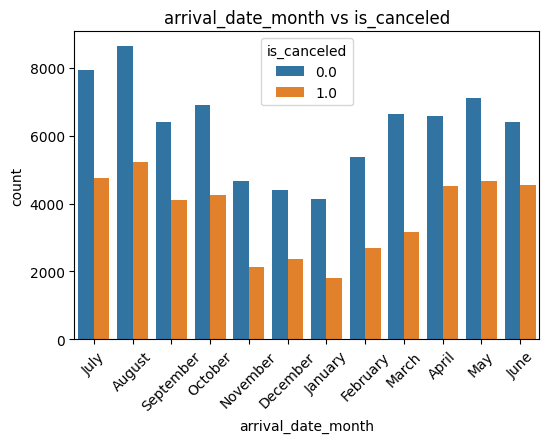

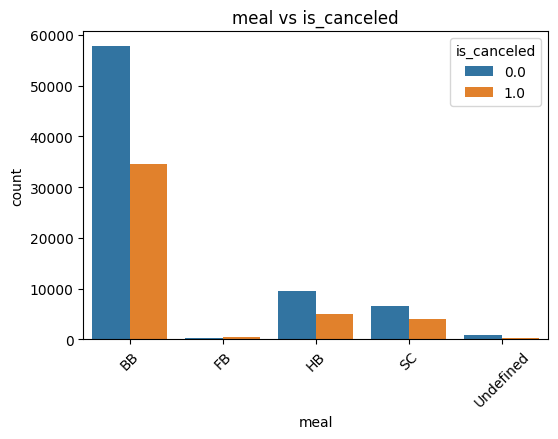

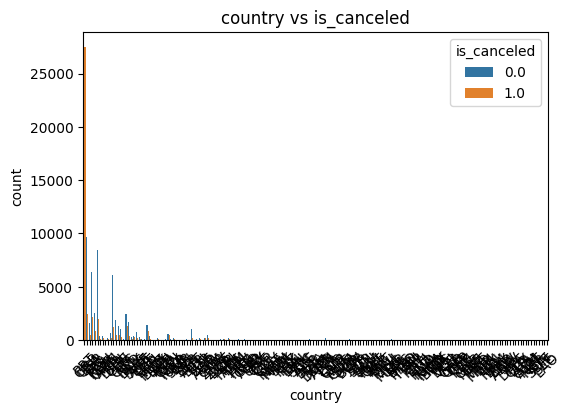

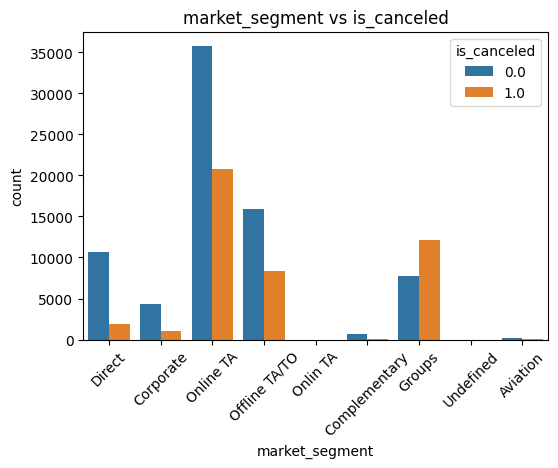

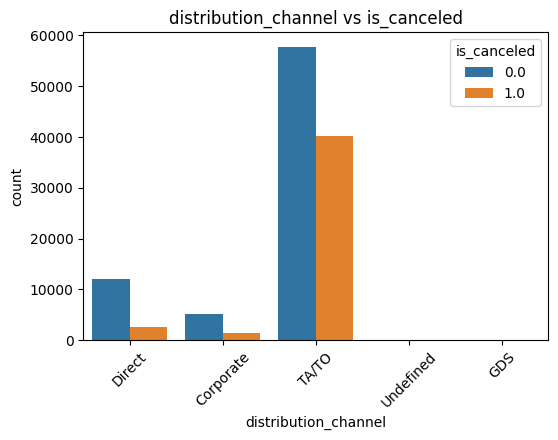

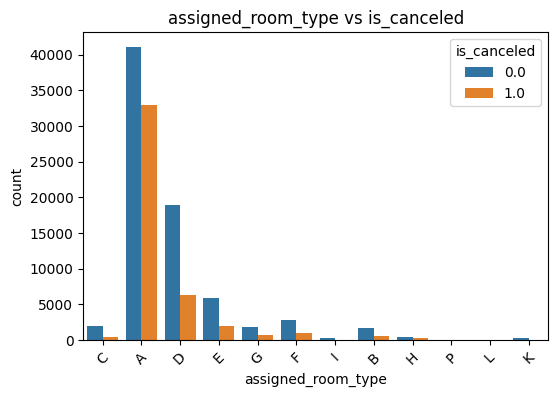

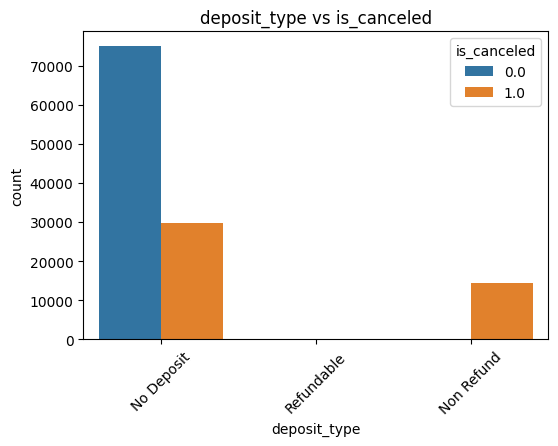

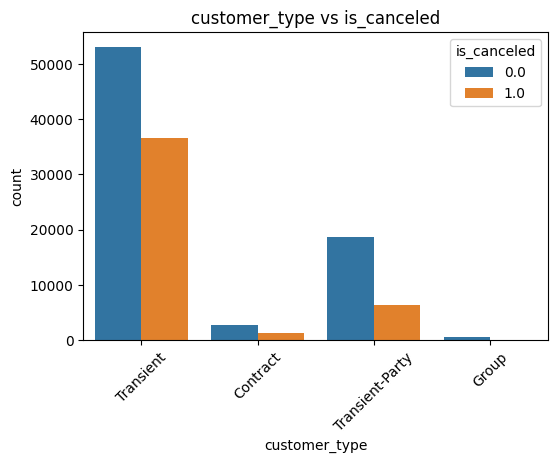

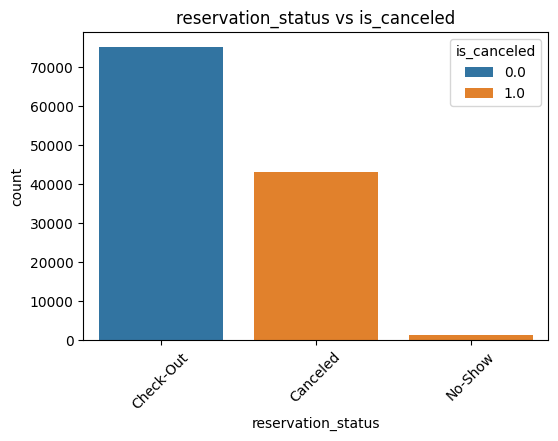

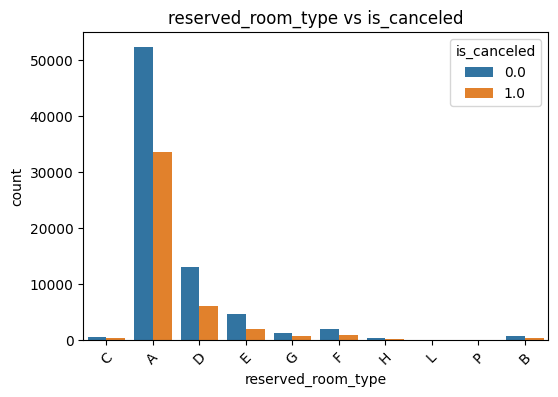

In [161]:
for col in categorical_attribute_names:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=data_df, x=col, hue="is_canceled")
    plt.title(f"{col} vs is_canceled")
    plt.xticks(rotation=45)
    plt.show()

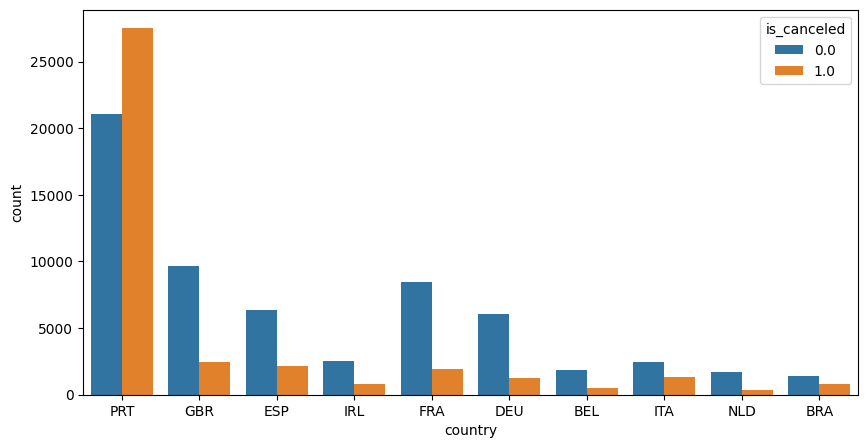

In [164]:
# investigate this country that has a very high count of cancelations.
top_countries = data_df["country"].value_counts().nlargest(10).index

df_top = data_df[data_df["country"].isin(top_countries)]
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_top,
    x="country",
    hue="is_canceled"
)
plt.show()

**Discussion:**
- It appears that when special requests are made or a required amount of cars is present, the booking is much less likely to be canceled.
- Lead time is another difference, wehere a longer lead time appears to contribute to a higher chance of cancellation.
- Most of these numerical attributes do not appear to have a huge impact on whether a booking was cancelled or not.

- Groups have a much higher chance of being canceled than not canceled.
- Additionally, the country PRT (portugal) has a very very high number of cancelations that actually out numbers the total non canceled events.

***
# Section: 3 - Data Preparation
In this step, the “final” target dataset is constructed (although nothing is ever final…), based on the insights gleaned in the Data Understanding step.
This may include:
- Normalizing / standardizing the data.
- Handling missing and erroneous data.
- Transforming or eliminating attributes.
- “Blending” data from multiple sources (with attention to consistency of the various sources).
- Deploying the data to storage in suitable formats, data models / structures.
***

***
## Section: 3.1 - Clean the Data
- Implement any data cleaning steps previously identified.  Please justify.
- Show the effects of that cleaning through the use of appropriate statistics and/or visualizations.
***

In [ ]:
data_df[data_df['is_canceled'].isna()] # this record is uselss without this col
# going to drop from the dataset since we have ~119000 records
data_df = data_df.dropna(subset=('is_canceled'))

**Discussion:**
- Please fill in a response...

***
## Section: 3.2 - Select Attributes
- Optionally, remove attributes that are unneeded, redundant, etc., for the expected uses.
- Which attributes did you decide to remove, if any? Please justify.
***

**Discussion:**
- Please fill in a response...

***
## Section: 3.3 - Create Attributes
- Optionally, create new attributes based on the values of other attibutes.
- Which new attributes did you decide to create, if any? Please justify.
***

**Discussion:**
- Please fill in a response...

***
## Section: 3.4 - Transform Attributes
- Optionally, transform existing attributes (e.g., standardize, normalize, change units of measure, encode) to make them more appropriate for the expected uses.
- Which attributes did you decide to transform, if any? Please justify.
***

**Discussion:**
- Please fill in a response...

***
## Section: 3.5 - Select Records
- Optionally, select a subset of the records, via sampling, etc., to decrease the size of the dataset. Please justify.
***

**Discussion:**
- Please fill in a response...

***
## Section: 3.6 - Other Data Preparation
- Optionally, perform other preparation steps (e.g., to optimize storage, retrieval, etc.). Please justify.
***

**Discussion:**
- Please fill in a response...

***
# Section: 4 - Modeling
In this step, the dataset is analyzed and used to create models and/or answer questions relevant to the business. This may include:
- Developing statistical models for describing or predicting business situations.
- Training data mining (e.g., machine learning) algorithms for classification, clustering, association analysis, outlier detection, and other uses.

NOTE: This step is tightly coupled and iterative with the Data Preparation and Evaluation steps.
***

As described in the instructions at the beginning of this notebook, you are encouraged to reuse the [K-Nearest Neighbors (KNN) code](https://bcoy48.github.io/osu-gradtda-5622-sp25/course_materials/sync_class/CRISP-DM_Template_V13%20-%20IRIS%20DATA.ipynb) provided within the Modeling & Evaluation asynchronous module. Below is an example of this code. Please note the choices you have to make for this specific model:  
* Select a desired value for the `K` parameter (desired number of neighbors).  
* Split the prepared data into training and tests datasets as desired.  
#  
```
#K-Nearest Neighbors Algorithm Example, via Python and Scikit-Learn
from sklearn.neighbors import KNeighborsClassifier

# Establish a desired value for k
knn_num_neighbors = 5   # Chosen as an illustrative example

# Instantiate the class and set the k variable value for this instance
classifier = KNeighborsClassifier(n_neighbors = knn_num_neighbors)

# Fit the instantiated KNN classifier model
classifier.fit(X_train, y_train)

# Generate the predictions for the Test data
y_pred = classifier.predict(X_test)
```  
---

**Discussion:**
- Please fill in a response...

***
# Section: 5 - Evaluation
In this step, the analyses and/or models are evaluated for quality and relevance / usefulness.

NOTE: This step is tightly coupled and iterative with the Modeling step.
***

**Discussion:**
- Please fill in a response...

***
# Section: 6 - Deployment
In this step, data and resulting models and/or analyses are put to use. This may include:
- Deploying data mining / machine learning algorithms to production.
- Communicating the results of the analyses to business stakeholders, so they can take action.
***

**Discussion:**
- Please fill in a response...

***
# Section: Conclusions
- What did you learn from this exercise?
***

Please fill in a response...